In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### plotting

division by zero msnbc DRX71AeCgTh 0 10
division by zero msnbc DRYGzcyEsGL 0 10


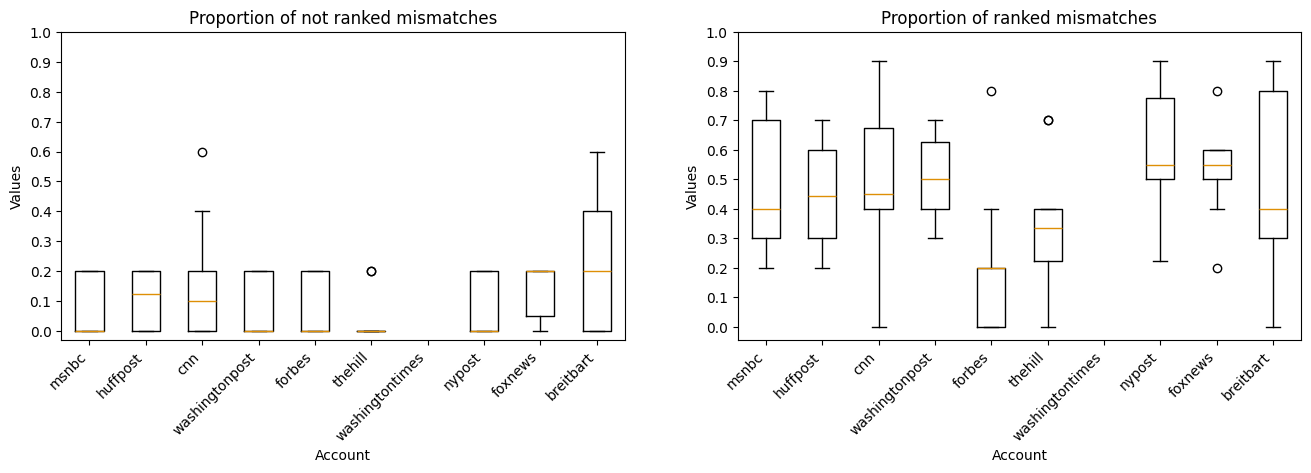

In [18]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'male_dem_ny_1'
crawl2 = 'female_rep_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRX7mPtkhbo 0 0
division by zero msnbc DRXeikNDutF 0 0
division by zero msnbc DRXyanzDw2z 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRX7mPtkhbo 0 0
division by zero msnbc DRXeikNDutF 0 0
division by zero msnbc DRXyanzDw2z 0 0
division by zero msnbc DRYGzcyEsGL 0 0


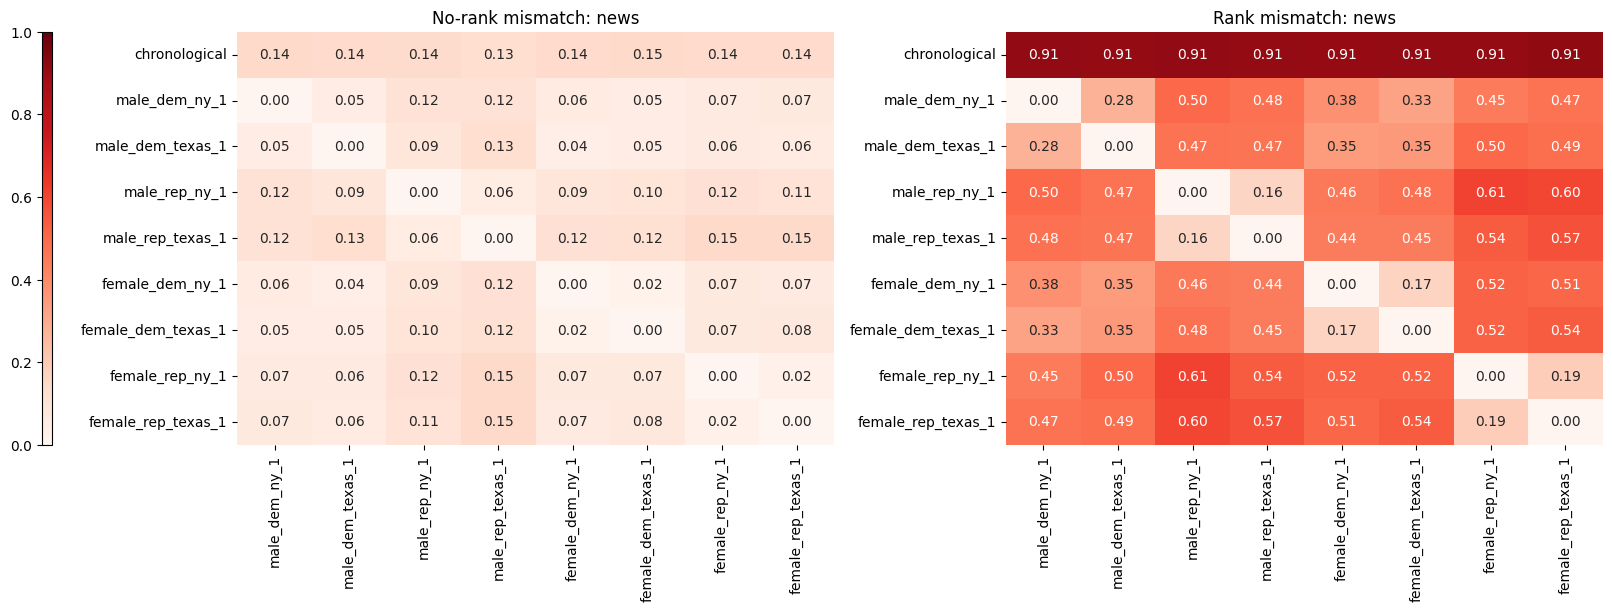

In [15]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in ['chronological'] + all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

hm0 = sns.heatmap(
    mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"No-rank mismatch: {flag}")

hm1 = sns.heatmap(
    mismatch_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Rank mismatch: {flag}")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="vertical",
    location="left", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.show()

### combined reg

In [15]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_nonnews_df = get_df_for_regression(nonnews_df, nonnews_urls, all_crawls) 

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 

In [16]:
reg_news_df.shape, reg_nonnews_df.shape

((4648, 9), (4312, 9))

In [17]:
reg_news_df.drop_duplicates(inplace=True)
reg_nonnews_df.drop_duplicates(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2121, 9), (2089, 9))

In [18]:
reg_news_df.dropna(inplace=True)
reg_nonnews_df.dropna(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2121, 9), (2089, 9))

In [19]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_nonnews_df = pd.merge(reg_nonnews_df, accounts_data, on='account', how='inner')
reg_nonnews_df.shape

(2089, 12)

In [20]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2121, 15)

In [21]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_nonnews_df = reg_nonnews_df.merge(comments_df, on='urlid', how='left')
reg_nonnews_df = reg_nonnews_df.merge(likes_df, on='urlid', how='left')

reg_nonnews_df[reg_nonnews_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [22]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [23]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')

reg_news_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,1394.000000,727.000000
mean,853.671449,1827.634113
std,2134.126414,3092.699244
min,14.000000,17.000000
25%,89.000000,116.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [24]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_mising"])
reg_news_df[['comments_count', 'comments_mising']].describe()
reg_news_df.drop(columns=['comments_mising'], inplace=True)

In [25]:
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['urlid'] != 'DSC60BKkrYV']

In [26]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2121, 21)

In [27]:
reg_news_df['type'] = 'News'
reg_nonnews_df['main_topic'] = 'Non-Political'
reg_nonnews_df['type'] = 'Non-News'

In [28]:
concat_df = pd.concat([reg_nonnews_df, reg_news_df], ignore_index=True)
concat_df.shape

(4189, 22)

In [29]:
concat_df['fcount_no_rank'] = concat_df['fcount_no_rank'].astype(int)
concat_df['ftrials_no_rank'] = concat_df['ftrials_no_rank'].astype(int)
concat_df['fcount_rank'] = concat_df['fcount_rank'].astype(int)
concat_df['ftrials_rank'] = concat_df['ftrials_rank'].astype(int)

(concat_df[concat_df['fcount_no_rank'] > concat_df['ftrials_no_rank']]).shape, (concat_df[concat_df['fcount_rank'] > concat_df['ftrials_rank']]).shape

((0, 22), (0, 22))

In [30]:
concat_df['gender_diff'] = concat_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
concat_df['location_diff'] = concat_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
concat_df['ideology_diff'] = concat_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [31]:
for col in ["posts", "followers", "following", "comments_count"]:
    new = col + "_logz"
    x = np.log1p(concat_df[col].astype(float))
    concat_df[new] = (x - x.mean()) / x.std(ddof=0)


concat_df["gender"] = pd.Categorical(
    concat_df["gender"],
    categories=["male_male", "female_male", "female_female"],
    ordered=True
)

concat_df["ideology"] = pd.Categorical(
    concat_df["ideology"],
    categories=["rep_rep", "dem_rep", "dem_dem"],
    ordered=True
)

concat_df["location"] = pd.Categorical(
    concat_df["location"],
    categories=["texas_texas", "ny_texas", "ny_ny"],
    ordered=True
)

concat_df['type'] = pd.Categorical(
    concat_df['type'],
    categories=['Non-News', 'News'],
    ordered=True
)


concat_df['main_topic'] = pd.Categorical(
    concat_df['main_topic'],
    categories=['Non-Political', 'Political'],
    ordered=True
)

concat_df["gender_diff"] = pd.Categorical(
    concat_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

concat_df["ideology_diff"] = pd.Categorical(
    concat_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

concat_df["location_diff"] = pd.Categorical(
    concat_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

In [32]:
concat_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,comments_count,likes_count,main_topic,type,political_ideology,reporting_quality,credibility,Brahmani_Topics,Divya_Topics,Hamayoon_Topics,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,DSB-0hjkQNx,accesshollywood,0,20,2,10,28864.0,1800000,1470,25.0,884.0,Non-Political,Non-News,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,0.508262,-0.694135,1.341024,-1.404571
1,ny_texas,male_male,dem_dem,DSBAeqRk4is,accesshollywood,10,20,6,10,28864.0,1800000,1470,846.0,2800.0,Non-Political,Non-News,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,0.508262,-0.694135,1.341024,0.903242
2,ny_texas,male_male,dem_dem,DSC5lsdkySq,accesshollywood,4,20,9,10,28864.0,1800000,1470,49.0,1900.0,Non-Political,Non-News,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,0.508262,-0.694135,1.341024,-0.971359
3,ny_texas,male_male,dem_dem,DSD1KHYkXtU,accesshollywood,2,20,3,10,28864.0,1800000,1470,19.0,2800.0,Non-Political,Non-News,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,0.508262,-0.694135,1.341024,-1.578382
4,ny_texas,male_male,dem_dem,DSDKXfBCjPl,accesshollywood,10,20,9,10,28864.0,1800000,1470,133.0,2200.0,Non-Political,Non-News,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,0.508262,-0.694135,1.341024,-0.318276


In [33]:
concat_df.duplicated().sum()

np.int64(0)

In [34]:
concat_df['main_topic'].value_counts(), concat_df['type'].value_counts() 

(main_topic
 Non-Political    3144
 Political        1045
 Name: count, dtype: int64,
 type
 News        2121
 Non-News    2068
 Name: count, dtype: int64)

In [35]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(type) + C(main_topic) + followers_logz + comments_count_logz + followers_logz + following_logz + posts_logz " 
get_vif(formula, concat_df)

,feature,VIF
8,following_logz,1.042193
1,gender_diff[T.Yes],1.082412
3,ideology_diff[T.Yes],1.084033
2,location_diff[T.Yes],1.092294
9,posts_logz,1.185065
6,followers_logz,1.274489
7,comments_count_logz,1.370502
4,C(type)[T.News],1.523143
5,C(main_topic)[T.Political],1.805873
0,Intercept,8.361651


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, followers_logz, comments_count_logz, type, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 661 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.956,0.132,-2.192,-1.696,0.004,0.002,1127.0,2190.0,1.0
location_diff[Yes],-0.203,0.039,-0.274,-0.129,0.000,0.000,12019.0,5582.0,1.0
gender_diff[Yes],0.155,0.039,0.080,0.224,0.000,0.000,10998.0,6182.0,1.0
ideology_diff[Yes],0.102,0.040,0.029,0.179,0.000,0.001,12623.0,5323.0,1.0
comments_count_logz,0.555,0.100,0.366,0.739,0.003,0.002,1187.0,2303.0,1.0
main_topic[Political],0.345,0.251,-0.115,0.831,0.007,0.004,1207.0,2262.0,1.0
type[News],-1.197,0.208,-1.570,-0.793,0.006,0.003,1289.0,2347.0,1.0
followers_logz,-0.193,0.097,-0.376,-0.011,0.003,0.001,855.0,2321.0,1.0


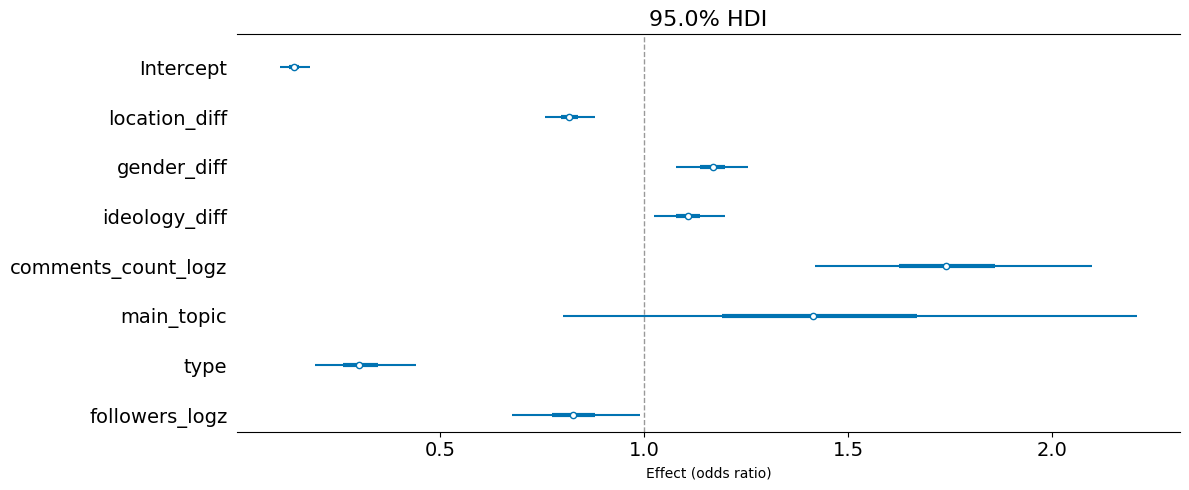

In [36]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + type + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'comments_count_logz', 'main_topic', 'type', 'followers_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Default computed for conditional variable: type
Default computed for unspecified variable: comments_count_logz, followers_logz, gender_diff, ideology_diff, location_diff, main_topic, urlid


(<Figure size 840x360 with 1 Axes>,
 array([<Axes: xlabel='type', ylabel='p(fcount_no_rank, ftrials_no_rank)'>],
       dtype=object))

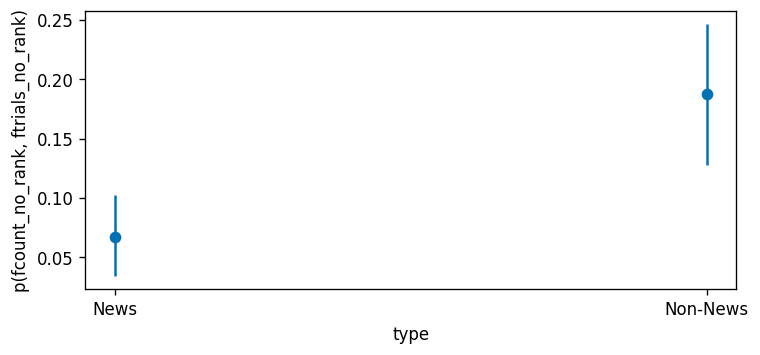

In [43]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model, results, conditional=['type'], ax=ax)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, followers_logz, comments_count_logz, type, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 727 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.362,0.142,-1.634,-1.099,0.004,0.002,1012.0,1958.0,1.0
location[ny_texas],-0.376,0.045,-0.465,-0.296,0.000,0.000,9955.0,6550.0,1.0
location[ny_ny],-0.365,0.053,-0.463,-0.265,0.001,0.001,9163.0,6344.0,1.0
gender[female_male],-0.175,0.045,-0.259,-0.089,0.000,0.000,10995.0,5799.0,1.0
gender[female_female],-0.721,0.059,-0.827,-0.605,0.001,0.001,10541.0,5828.0,1.0
ideology[dem_rep],-0.007,0.046,-0.090,0.082,0.000,0.000,9670.0,6343.0,1.0
ideology[dem_dem],-0.208,0.057,-0.310,-0.100,0.001,0.001,10742.0,6072.0,1.0
comments_count_logz,0.554,0.103,0.363,0.744,0.003,0.002,1201.0,2355.0,1.0
main_topic[Political],0.368,0.253,-0.085,0.853,0.007,0.004,1141.0,1904.0,1.0
type[News],-1.218,0.218,-1.637,-0.808,0.007,0.003,1021.0,2119.0,1.0


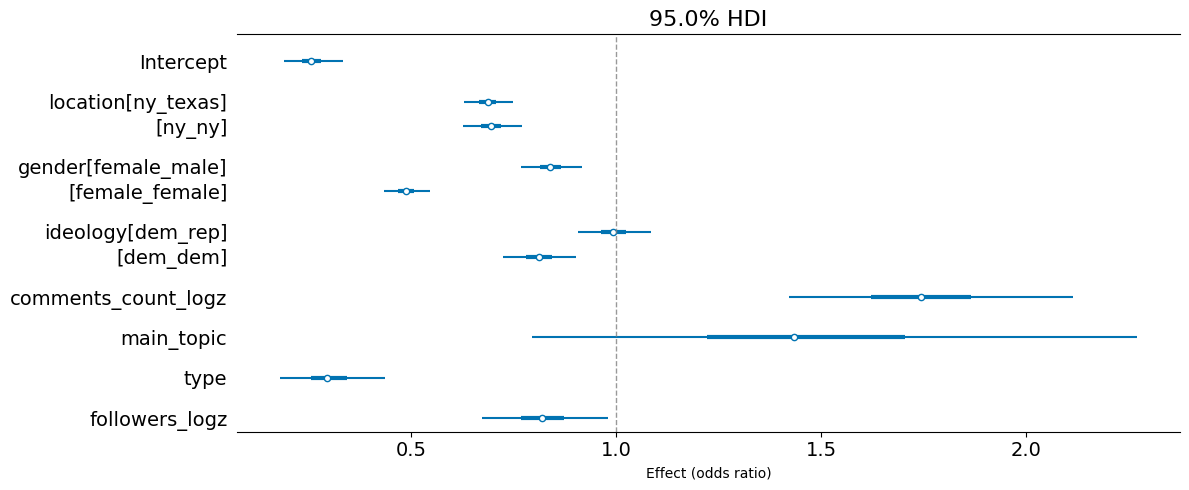

In [40]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + followers_logz + comments_count_logz + type + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
var_names = ['Intercept', 'location', 'gender', 'ideology', 'comments_count_logz', 'main_topic', 'type', 'followers_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

#### only type reg

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, type, posts_logz, followers_logz, following_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 152 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
type[News],-0.733,0.190,-1.070,-0.367,0.008,0.004,623.0,1409.0,1.01
posts_logz,-0.141,0.100,-0.344,0.032,0.004,0.002,688.0,1203.0,1.00
followers_logz,0.011,0.092,-0.158,0.187,0.004,0.002,659.0,1257.0,1.01
following_logz,0.276,0.097,0.099,0.463,0.004,0.002,659.0,1424.0,1.01


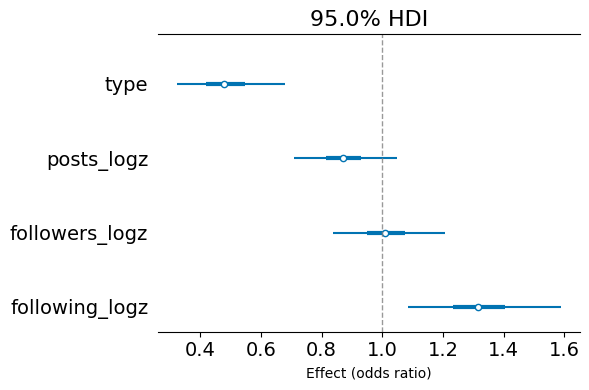

In [31]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ type + posts_logz + followers_logz + following_logz + (1|urlid)",
#     data=concat_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=4,
#     random_seed=42,
# )

# var_names = ['type', 'posts_logz', 'followers_logz', 'following_logz']
# display(az.summary(results, var_names=var_names))

# axes = az.plot_forest(
#     results,
#     combined=True,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(6, 4),
#     r_hat=False,
#     ess=False,
#     var_names = var_names
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, type, posts_logz, followers_logz, following_logz, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 145 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
type[News],-1.067,0.179,-1.403,-0.729,0.007,0.004,627.0,997.0,1.01
posts_logz,-0.041,0.087,-0.207,0.123,0.004,0.002,591.0,943.0,1.01
followers_logz,-0.179,0.090,-0.346,-0.005,0.003,0.002,771.0,892.0,1.00
following_logz,0.295,0.085,0.127,0.447,0.003,0.002,798.0,1436.0,1.00
comments_count_logz,0.587,0.091,0.405,0.754,0.003,0.002,734.0,1324.0,1.01


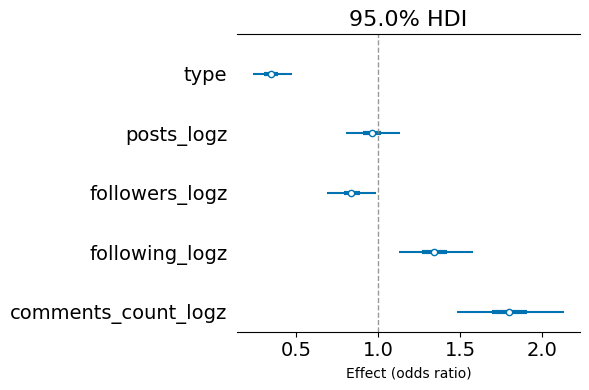

In [32]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ type + posts_logz + followers_logz + following_logz + comments_count_logz + (1|urlid)",
#     data=concat_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=4,
#     random_seed=42,
# )

# var_names = ['type', 'posts_logz', 'followers_logz', 'following_logz', 'comments_count_logz']
# display(az.summary(results, var_names=var_names))

# axes = az.plot_forest(
#     results,
#     combined=True,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(6, 4),
#     r_hat=False,
#     ess=False,
#     var_names = var_names
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, type, comments_count_logz, type:comments_count_logz, posts_logz, followers_logz, following_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 589 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
type[News],-1.096,0.178,-1.425,-0.760,0.006,0.003,1041.0,1927.0,1.00
posts_logz,-0.058,0.089,-0.228,0.104,0.003,0.002,1036.0,2027.0,1.01
followers_logz,-0.178,0.087,-0.339,-0.014,0.003,0.001,1117.0,1968.0,1.00
following_logz,0.306,0.084,0.148,0.461,0.003,0.001,922.0,1997.0,1.00
comments_count_logz,0.681,0.142,0.418,0.945,0.005,0.003,813.0,1745.0,1.01
type:comments_count_logz[News],-0.152,0.181,-0.503,0.179,0.006,0.003,902.0,1715.0,1.00


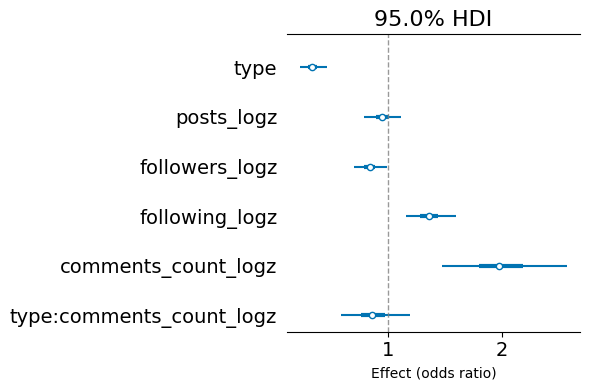

In [33]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ type * comments_count_logz + posts_logz + followers_logz + following_logz + (1|urlid)",
#     data=concat_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results3 = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.95,
#     chains=4,
#     cores=1,
#     random_seed=42,
# )

# var_names = ['type', 'posts_logz', 'followers_logz', 'following_logz', 'comments_count_logz', 'type:comments_count_logz']
# display(az.summary(results3, var_names=var_names))

# axes = az.plot_forest(
#     results3,
#     combined=True,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(6, 4),
#     r_hat=False,
#     ess=False,
#     var_names = var_names
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

### only news reg: post level

In [15]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_news_df.shape

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0


(4648, 9)

In [16]:
reg_news_df.drop_duplicates(inplace=True)
reg_news_df.shape

(2121, 9)

In [17]:
reg_news_df.dropna(inplace=True)
reg_news_df.shape

(2121, 9)

In [18]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2121, 15)

In [19]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [20]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')
reg_news_df.shape

(2121, 18)

In [21]:
reg_news_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,1394.000000,727.000000
mean,853.671449,1827.634113
std,2134.126414,3092.699244
min,14.000000,17.000000
25%,89.000000,116.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [22]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_mising"])
reg_news_df[['comments_count', 'comments_mising']].describe()
reg_news_df.drop(columns=['comments_mising'], inplace=True)

In [23]:
reg_news_df['fcount_no_rank'] = reg_news_df['fcount_no_rank'].astype(int)
reg_news_df['ftrials_no_rank'] = reg_news_df['ftrials_no_rank'].astype(int)
reg_news_df['fcount_rank'] = reg_news_df['fcount_rank'].astype(int)
reg_news_df['ftrials_rank'] = reg_news_df['ftrials_rank'].astype(int)

(reg_news_df[reg_news_df['fcount_no_rank'] > reg_news_df['ftrials_no_rank']]).shape, (reg_news_df[reg_news_df['fcount_rank'] > reg_news_df['ftrials_rank']]).shape

((0, 17), (0, 17))

In [24]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2121, 21)

In [25]:
reg_news_df['political_ideology'] = reg_news_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_news_df['political_ideology'].value_counts()

political_ideology
Left      941
Right     754
Center    426
Name: count, dtype: int64

In [26]:
reg_news_df['gender_diff'] = reg_news_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_news_df['location_diff'] = reg_news_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_news_df['ideology_diff'] = reg_news_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [32]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_news_df[col].astype(float))
    reg_news_df[new_col] = (x - x.mean()) / x.std()

reg_news_df["gender"] = pd.Categorical(
    reg_news_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_news_df["ideology"] = pd.Categorical(
    reg_news_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_news_df["location"] = pd.Categorical(
    reg_news_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_news_df['main_topic'] = pd.Categorical(
    reg_news_df['main_topic'],
    categories=['Political', 'Non-Political'],
    ordered=True
)

reg_news_df["gender_diff"] = pd.Categorical(
    reg_news_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_news_df["ideology_diff"] = pd.Categorical(
    reg_news_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_news_df["location_diff"] = pd.Categorical(
    reg_news_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

In [33]:
reg_news_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,Brahmani_Topics,Divya_Topics,Hamayoon_Topics,main_topic,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,DRK7-xAEaGg,thehill,0,18,2,9,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,No,Yes,No,0.037838,-2.151076,-2.10613,-0.406964
1,ny_ny,male_male,dem_rep,DRK7-xAEaGg,thehill,3,19,5,10,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,No,No,Yes,0.037838,-2.151076,-2.10613,-0.406964
2,ny_texas,male_male,dem_rep,DRK7-xAEaGg,thehill,3,19,5,10,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,No,Yes,Yes,0.037838,-2.151076,-2.10613,-0.406964
3,ny_ny,female_male,dem_dem,DRK7-xAEaGg,thehill,0,18,0,9,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,Yes,No,No,0.037838,-2.151076,-2.10613,-0.406964
4,ny_texas,female_male,dem_dem,DRK7-xAEaGg,thehill,0,18,0,9,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,Yes,Yes,No,0.037838,-2.151076,-2.10613,-0.406964


In [34]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(reporting_quality) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(main_topic) + followers_logz + comments_count_logz" 
get_vif(formula, reg_news_df)

,feature,VIF
1,gender_diff[T.Yes],1.089243
3,ideology_diff[T.Yes],1.089749
2,location_diff[T.Yes],1.104900
8,comments_count_logz,1.397342
6,C(main_topic)[T.Non-Political],1.576336
7,followers_logz,1.717379
5,C(political_ideology)[T.Right],2.133285
4,C(political_ideology)[T.Left],2.740759
0,Intercept,14.454839


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, political_ideology, comments_count_logz, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 70 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.786,0.404,-3.531,-2.021,0.015,0.011,694.0,1255.0,1.00
location_diff[Yes],-0.257,0.059,-0.365,-0.146,0.001,0.001,6335.0,5614.0,1.00
gender_diff[Yes],0.240,0.059,0.127,0.349,0.001,0.001,5510.0,5736.0,1.00
ideology_diff[Yes],0.320,0.060,0.209,0.434,0.001,0.001,5510.0,5637.0,1.00
political_ideology[Left],0.095,0.460,-0.779,0.931,0.018,0.012,631.0,909.0,1.00
political_ideology[Right],-0.030,0.465,-0.948,0.810,0.019,0.010,609.0,822.0,1.00
comments_count_logz,0.498,0.175,0.148,0.807,0.007,0.004,633.0,1108.0,1.01
main_topic[Non-Political],-0.524,0.328,-1.105,0.151,0.013,0.008,657.0,1014.0,1.01


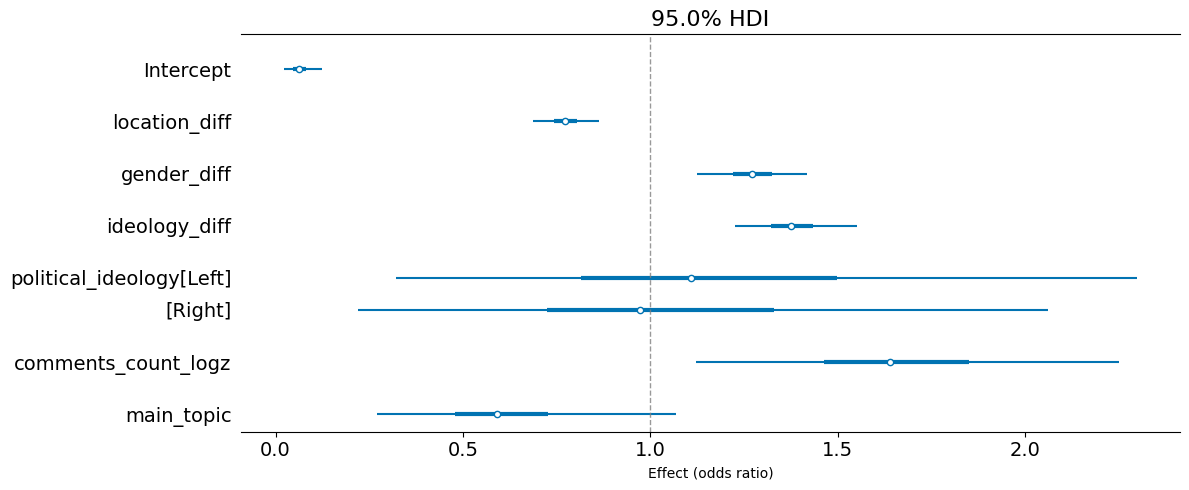

In [35]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + political_ideology + comments_count_logz + main_topic + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'political_ideology', 'comments_count_logz', 'main_topic']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location, gender, ideology, political_ideology, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 93 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-4.008,0.388,-4.746,-3.288,0.012,0.007,1095.0,1726.0,1.00
location[texas_texas],0.154,0.076,0.015,0.301,0.001,0.001,5668.0,5795.0,1.00
location[ny_texas],-0.185,0.069,-0.314,-0.054,0.001,0.001,6059.0,5682.0,1.00
gender[male_male],0.659,0.090,0.491,0.829,0.001,0.001,5019.0,5105.0,1.00
gender[female_male],0.607,0.079,0.468,0.762,0.001,0.001,5347.0,4846.0,1.00
ideology[rep_rep],0.928,0.092,0.764,1.106,0.001,0.001,4711.0,5546.0,1.00
ideology[dem_rep],0.826,0.083,0.676,0.989,0.001,0.001,4456.0,5192.0,1.00
political_ideology[Left],0.139,0.464,-0.731,1.023,0.016,0.008,884.0,1469.0,1.00
political_ideology[Right],-0.187,0.460,-1.055,0.687,0.014,0.008,1020.0,1948.0,1.00
comments_count_logz,0.576,0.181,0.222,0.905,0.006,0.003,1000.0,1695.0,1.01


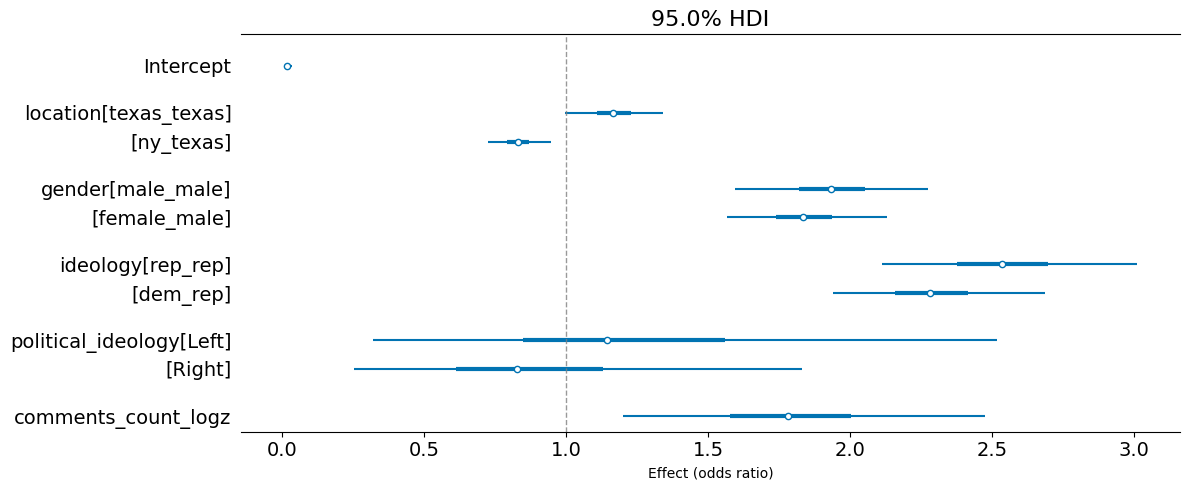

In [36]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + political_ideology + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    random_seed=42,
)
var_names = ['Intercept', 'location', 'gender', 'ideology', 'political_ideology', 'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, political_ideology, ideology_diff:political_ideology, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 98 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.122,0.373,-3.796,-2.418,0.012,0.007,907.0,1852.0,1.0
location_diff[Yes],-0.256,0.058,-0.363,-0.146,0.001,0.001,6537.0,5313.0,1.0
gender_diff[Yes],0.238,0.060,0.127,0.353,0.001,0.001,5322.0,5240.0,1.0
ideology_diff[Yes],0.518,0.156,0.222,0.818,0.003,0.002,2610.0,3694.0,1.0
political_ideology[Left],0.256,0.459,-0.569,1.146,0.016,0.009,826.0,1483.0,1.0
political_ideology[Right],-0.047,0.468,-0.969,0.797,0.017,0.008,796.0,1750.0,1.0
comments_count_logz,0.569,0.173,0.267,0.914,0.006,0.003,865.0,1366.0,1.0
"ideology_diff:political_ideology[Yes, Left]",-0.248,0.176,-0.572,0.091,0.003,0.002,2829.0,3978.0,1.0
"ideology_diff:political_ideology[Yes, Right]",-0.205,0.183,-0.556,0.136,0.003,0.002,2991.0,4430.0,1.0


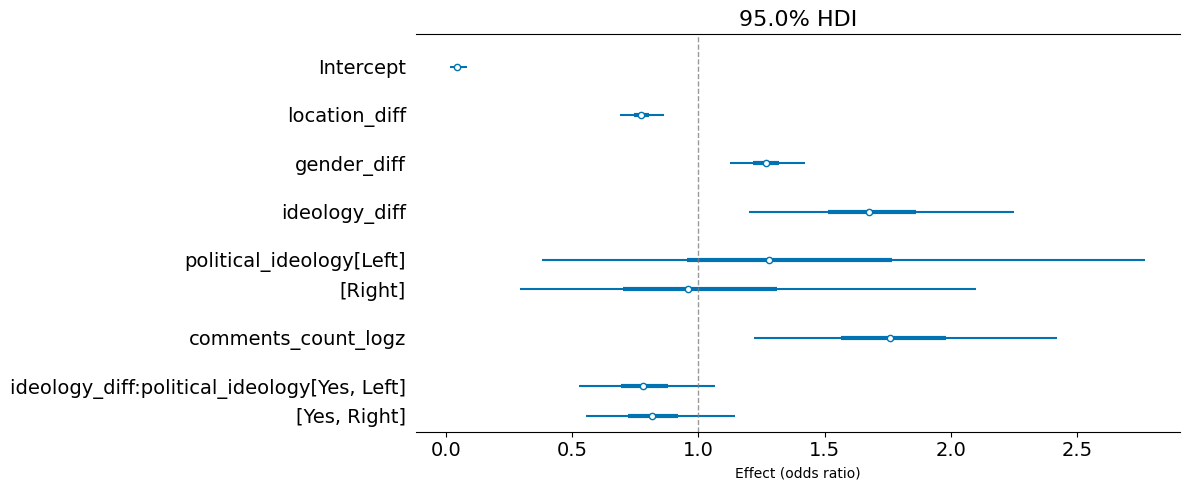

In [37]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff * political_ideology + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'political_ideology', 'comments_count_logz', 'ideology_diff:political_ideology']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location, gender, ideology_diff, political_ideology, ideology_diff:political_ideology, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 99 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.566,0.387,-4.315,-2.874,0.011,0.006,1173.0,2225.0,1.0
location[texas_texas],0.134,0.078,-0.012,0.279,0.001,0.001,5417.0,5616.0,1.0
location[ny_texas],-0.192,0.071,-0.324,-0.059,0.001,0.001,5442.0,5070.0,1.0
gender[male_male],0.639,0.089,0.474,0.811,0.001,0.001,5020.0,5228.0,1.0
gender[female_male],0.575,0.079,0.424,0.721,0.001,0.001,4866.0,5440.0,1.0
ideology_diff[Yes],0.534,0.153,0.257,0.834,0.003,0.002,2611.0,2947.0,1.0
political_ideology[Left],0.285,0.462,-0.589,1.143,0.014,0.008,1075.0,2071.0,1.0
political_ideology[Right],-0.032,0.469,-0.897,0.855,0.014,0.008,1086.0,2024.0,1.0
comments_count_logz,0.565,0.174,0.251,0.903,0.005,0.003,1017.0,2010.0,1.0
"ideology_diff:political_ideology[Yes, Left]",-0.270,0.171,-0.596,0.049,0.003,0.002,2952.0,3667.0,1.0


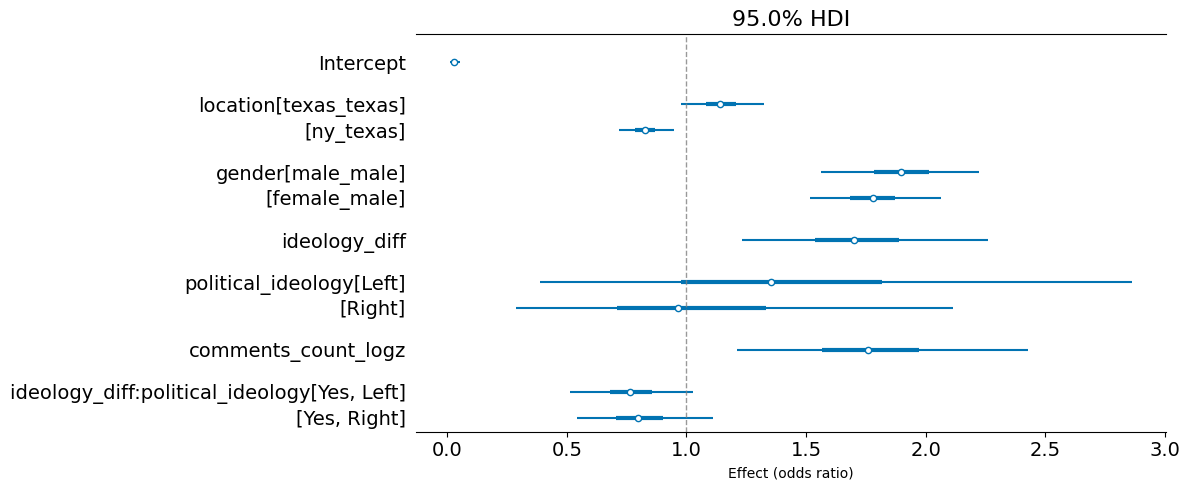

In [38]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology_diff * political_ideology + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    random_seed=42,
)
var_names = ['Intercept', 'location', 'gender', 'ideology_diff', 'political_ideology', 'comments_count_logz', 'ideology_diff:political_ideology']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

### only news: comment level

In [15]:
news_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv')
news_df.shape

(1279, 13)

In [16]:
news_df.dropna(subset=['caption'], inplace=True)
news_df.shape

(1129, 13)

In [17]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [18]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [19]:
news_df.shape

(830, 14)

In [20]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == ' ':
                news_df.loc[i, col] = f'{(x[0], "empty")}'

In [21]:
for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == 'empty':
                print(x)

('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')


In [22]:
for url in news_df['urlid'].unique().tolist():
    if news_df[news_df['urlid'] == url]['caption_text'].nunique() != 1:
        print(url, news_df[news_df['urlid'] == url]['caption_text'].nunique())

In [23]:
url_caption_map = {}

for url in news_df['urlid'].unique().tolist():
    comments = news_df[news_df['urlid'] == url]['caption_text'].unique()[0]

    url_caption_map[url] = comments

In [24]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

comment_caption_map = {}
for caption in news_df['caption_text'].tolist():
    if caption not in comment_caption_map:
        comment_caption_map[caption] = []
    for col in cols:
        temp = news_df[news_df['caption_text'] == caption][col].tolist()
        comment_caption_map[caption] += temp

    comment_caption_map[caption] = list(set(comment_caption_map[caption]))

In [25]:
count = 0

for k, v in comment_caption_map.items():
    count+=len(v)

count

991

In [26]:
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

In [27]:
labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='gpt annotations no account')
# labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='annotations ideology')
labels_df.shape

(1013, 4)

In [28]:
labels_df['comment'] = labels_df['comment'].fillna('empty')

In [29]:
labels_df.rename(columns={'caption': 'caption_text'}, inplace=True)

In [30]:
url_caption_map_reverse = {v:k for k, v in url_caption_map.items()}
len(url_caption_map_reverse) == len(url_caption_map)

True

In [31]:
for x in url_caption_map_reverse:
    if 'lemme' in x.lower():
        print(x, url_caption_map_reverse[x])

'LEMME SHOW YOU': A police officer in New Mexico turned a quick visit to a basketball court into a highlight, teaching teens the “skyhook,” made famous by NBA legend Kareem Abdul-Jabbar, and sinking an unbelievable trick shot. DRYXH9GlIcS


In [32]:
labels_df['urlid'] = labels_df['caption_text'].apply(lambda x: url_caption_map_reverse[x] if x in url_caption_map_reverse else 'DRYXH9GlIcS')
labels_df[labels_df['urlid'] == 'DRYXH9GlIcS']

,username,caption_text,comment,label,urlid
412,jayce_united,LEMME SHOW YOU': A police officer in New Mexic...,Police officer ballin 🏀 👮,Supportive,DRYXH9GlIcS
413,oceandm514,LEMME SHOW YOU': A police officer in New Mexic...,"Good officer, the kids won’t forget❤️",Supportive,DRYXH9GlIcS
414,hawk.4532998,LEMME SHOW YOU': A police officer in New Mexic...,It's great that traffic officers take a little...,Supportive,DRYXH9GlIcS
415,zachbreeden1,LEMME SHOW YOU': A police officer in New Mexic...,That's a cool cop right there,Supportive,DRYXH9GlIcS
416,rylee.xmas,LEMME SHOW YOU': A police officer in New Mexic...,See police are cool its a certain group of peo...,Supportive,DRYXH9GlIcS
417,brandon.reflects,LEMME SHOW YOU': A police officer in New Mexic...,We have a code 6-7. Do you copy?,Neutral,DRYXH9GlIcS
418,yourdistractions,LEMME SHOW YOU': A police officer in New Mexic...,Good interactions with teens is what more poli...,Supportive,DRYXH9GlIcS
419,aldominguez17,LEMME SHOW YOU': A police officer in New Mexic...,It's easier to be kind,Supportive,DRYXH9GlIcS
420,chasevanarman24,LEMME SHOW YOU': A police officer in New Mexic...,That’s how u serve and protect the communityyyyy,Supportive,DRYXH9GlIcS
421,corey01852,LEMME SHOW YOU': A police officer in New Mexic...,Why he sound like Johnny hamcheck,Neutral,DRYXH9GlIcS


In [33]:
labels_df['comment_combined'] = labels_df.apply(lambda x: (x['username'], x['comment']), axis=1)
labels_df

,username,caption_text,comment,label,urlid,comment_combined
0,terp00,Speaking to Editor-in-Chief Alex Marlow @marlo...,Maga died when trump went Israel first over Am...,Against,DRWBiQXDG0H,"(terp00, Maga died when trump went Israel firs..."
1,alton_klompus,Speaking to Editor-in-Chief Alex Marlow @marlo...,@wearebreitbart slowly distancing themselves f...,Supportive,DRWBiQXDG0H,"(alton_klompus, @wearebreitbart slowly distanc..."
2,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,AMERICA FIRST !! ONLY !! THE CORPORATE RINOS M...,Supportive,DRWBiQXDG0H,"(i_tr00per, AMERICA FIRST !! ONLY !! THE CORPO..."
3,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,WE ARE NOT COMING TOGETHER UNTIL THE GOP BECOM...,Against,DRWBiQXDG0H,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T..."
4,loretta.bauer.35,Speaking to Editor-in-Chief Alex Marlow @marlo...,I thought that was exactly why we voted for Tr...,Supportive,DRWBiQXDG0H,"(loretta.bauer.35, I thought that was exactly ..."
...,...,...,...,...,...,...
1008,return_of__the_mack,In an era defined by major political divisions...,Ban lobbying and politics will change,Supportive,DRYMvrrFks8,"(return_of__the_mack, Ban lobbying and politic..."
1009,gwyneddstuart,In an era defined by major political divisions...,The call is coming from inside the building,Against,DRYMvrrFks8,"(gwyneddstuart, The call is coming from inside..."
1010,brianmpalmieri,In an era defined by major political divisions...,We need to take back at least half of their co...,Against,DRYMvrrFks8,"(brianmpalmieri, We need to take back at least..."
1011,jim.emerick.9,In an era defined by major political divisions...,They are 50% of maga donors...,Neutral,DRYMvrrFks8,"(jim.emerick.9, They are 50% of maga donors...)"


In [34]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    news_df[f'{col}_label'] = news_df[col].apply(lambda x: labels_df[labels_df['comment_combined'] == ast.literal_eval(x)]['label'].values[0] if pd.notna(x) else None)

In [35]:
for col in cols:
    print(news_df[f'{col}_label'].isna().sum(), col, news_df[f'{col}'].isna().sum())

30 male_dem_ny_1_comment 30
9 male_dem_texas_1_comment 9
0 male_rep_ny_1_comment 0
51 male_rep_texas_1_comment 51
9 female_dem_ny_1_comment 9
10 female_dem_texas_1_comment 10
12 female_rep_ny_1_comment 12
11 female_rep_texas_1_comment 11


In [36]:
news_df.shape

(830, 22)

In [37]:
reg_df = get_df_for_regression_comments(news_df, all_crawls, labels_df)

In [38]:
reg_df.drop_duplicates(inplace=True)
reg_df.shape

(24660, 12)

In [39]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_df['urlid'].nunique()

reg_df = pd.merge(reg_df, posts_data, on='urlid', how='inner')
reg_df.drop(columns=['Url'], inplace=True)
reg_df.drop(columns=['Brahmani_Topics', 'Divya_Topics', 'Hamayoon_Topics'], inplace=True)
reg_df.shape

(24660, 13)

In [40]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(24660, 19)

In [41]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_df =reg_df.merge(comments_df, on='urlid', how='left')
reg_df =reg_df.merge(likes_df, on='urlid', how='left')

reg_df[reg_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [42]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='urlid', how='outer')
reg_df.shape

(24660, 22)

In [43]:
reg_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,16386.000000,8274.000000
mean,841.307030,1823.258883
std,2101.013304,3005.806902
min,14.000000,17.000000
25%,89.000000,119.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [44]:
reg_df['comments_count'] = reg_df["comments_count"].fillna(reg_df["comments_mising"])
reg_df[['comments_count', 'comments_mising']].describe()
reg_df.drop(columns=['comments_mising'], inplace=True)

In [45]:
reg_df['political_ideology'] = reg_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_df['political_ideology'].value_counts()

political_ideology
Left      10827
Right      8648
Center     5185
Name: count, dtype: int64

In [46]:
reg_df['gender_diff'] = reg_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_df['location_diff'] = reg_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_df['ideology_diff'] = reg_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [47]:
reg_df['presence_no_rank'] = reg_df['presence_no_rank'].map({'Yes': 0, 'No': 1})

In [48]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_df[col].astype(float))
    reg_df[new_col] = (x - x.mean()) / x.std()

reg_df["gender"] = pd.Categorical(
    reg_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_df["ideology"] = pd.Categorical(
    reg_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_df["location"] = pd.Categorical(
    reg_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_df['main_topic'] = pd.Categorical(
    reg_df['main_topic'],
    categories=['Political', 'Non-Political'],
    ordered=True
)

reg_df["gender_diff"] = pd.Categorical(
    reg_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["ideology_diff"] = pd.Categorical(
    reg_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["location_diff"] = pd.Categorical(
    reg_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

# reg_df['presence_no_rank'] = pd.Categorical(
#     reg_df["presence_no_rank"],
#     categories=["No", "Yes"],
#     ordered=True
# )

reg_df['label'] = pd.Categorical(
    reg_df["label"],
    # categories=["Right leaning", "Neutral", "Left leaning"],
    categories=["Against", "Supportive", "Neutral"],
    ordered=True
)

In [49]:
reg_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('rob_flornandez', ""I like how he always claim...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('terrybear32', '#indefensible')",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('jgreer606', 'Says the guy trying to cancel c...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('midnight_max28', '“If Tucker wants to interv...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('patsyfowler62', ""Does anyone have doubts abo...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24655,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('travellingtrunk101', '👏👏👏👏👏👏👏')",1,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24656,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('tarterken', 'Bravo!')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24657,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('ivankuhn36', 'Go ICE! 👊💥🇺🇸')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24658,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('jeanne.sims.524', 'All discussing')",0,None,Neutral,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341


In [50]:
reg_df['presence_no_rank'].value_counts()

presence_no_rank
0    20896
1     3764
Name: count, dtype: int64

In [51]:
reg_df['label'].value_counts()

label
Supportive    10282
Against        9145
Neutral        5233
Name: count, dtype: int64

In [52]:
formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(political_ideology) + C(main_topic) + comments_count_logz"  
get_vif(formula, reg_df)

,feature,VIF
2,location_diff[T.Yes],1.066613
1,gender_diff[T.Yes],1.073363
3,ideology_diff[T.Yes],1.073840
8,C(main_topic)[T.Non-Political],1.204891
5,C(label)[T.Neutral],1.273075
4,C(label)[T.Supportive],1.285156
9,comments_count_logz,1.351053
7,C(political_ideology)[T.Right],2.048198
6,C(political_ideology)[T.Left],2.156997
0,Intercept,13.876618


In [53]:
url_pair_counts = (
    reg_df[['urlid', 'pair_id']]
    .value_counts()
    .reset_index(name='count')
)

url_pair_counts

reg_df = pd.merge(reg_df, url_pair_counts, on=['urlid', 'pair_id'], how='outer')
reg_df['weights'] = 1/reg_df['count']

In [54]:
reg_df[reg_df['presence_no_rank'] == 1]['urlid'].value_counts()

urlid
DRXBM5Ojq4P    218
DRYGzcyEsGL    158
DRX71AeCgTh    138
DRXD15DkpPm    114
DRXeikNDutF    110
              ... 
DRYdxYRDMFJ     16
DRVAqK1AYIk     14
DRYRxGYAUPl     14
DRYTefyEV_e     14
DRNeXQakhum     12
Name: count, Length: 69, dtype: int64

In [55]:
news_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(0)

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1116 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.875,0.734,-7.251,-4.492,0.010,0.008,5747.0,5612.0,1.0
location_diff[Yes],-0.306,0.059,-0.416,-0.194,0.000,0.001,17378.0,5786.0,1.0
gender_diff[Yes],0.406,0.060,0.289,0.514,0.000,0.001,19023.0,6253.0,1.0
ideology_diff[Yes],0.439,0.062,0.319,0.553,0.000,0.001,18257.0,5994.0,1.0
label[Supportive],-1.455,0.533,-2.472,-0.485,0.009,0.006,3840.0,4885.0,1.0
label[Neutral],-0.499,0.576,-1.595,0.580,0.009,0.006,3879.0,4913.0,1.0
political_ideology[Left],0.656,0.727,-0.724,2.043,0.008,0.008,9056.0,6434.0,1.0
political_ideology[Right],-0.440,0.751,-1.787,1.034,0.008,0.008,8121.0,5521.0,1.0
comments_count_logz,1.391,0.404,0.651,2.178,0.006,0.004,4999.0,5219.0,1.0


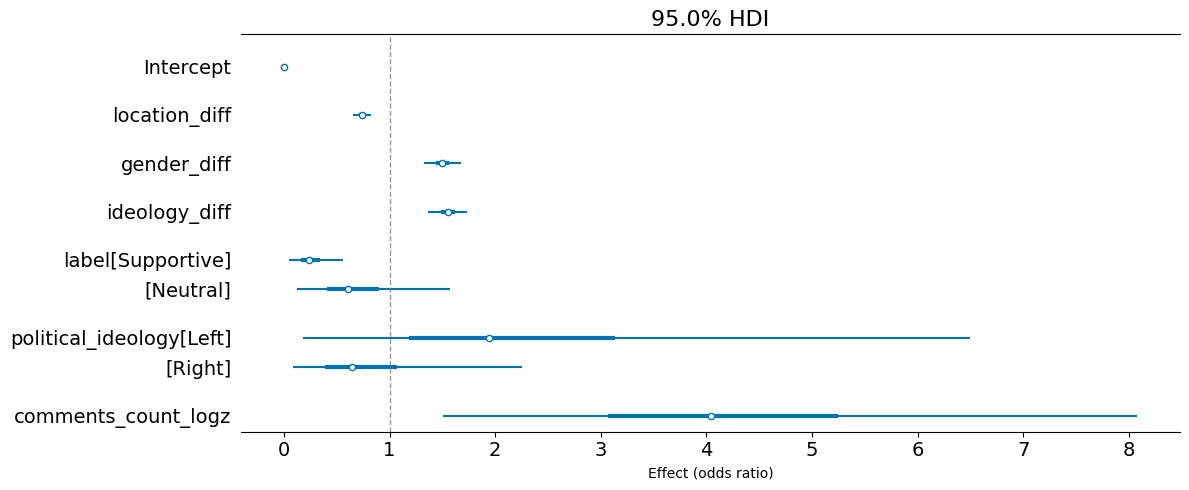

In [56]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
    data=reg_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    weights = reg_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1102 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.875,0.734,-7.251,-4.492,0.010,0.008,5747.0,5612.0,1.0
location_diff[Yes],-0.306,0.059,-0.416,-0.194,0.000,0.001,17378.0,5786.0,1.0
gender_diff[Yes],0.406,0.060,0.289,0.514,0.000,0.001,19023.0,6253.0,1.0
ideology_diff[Yes],0.439,0.062,0.319,0.553,0.000,0.001,18257.0,5994.0,1.0
label[Supportive],-1.455,0.533,-2.472,-0.485,0.009,0.006,3840.0,4885.0,1.0
label[Neutral],-0.499,0.576,-1.595,0.580,0.009,0.006,3879.0,4913.0,1.0
political_ideology[Left],0.656,0.727,-0.724,2.043,0.008,0.008,9056.0,6434.0,1.0
political_ideology[Right],-0.440,0.751,-1.787,1.034,0.008,0.008,8121.0,5521.0,1.0
comments_count_logz,1.391,0.404,0.651,2.178,0.006,0.004,4999.0,5219.0,1.0


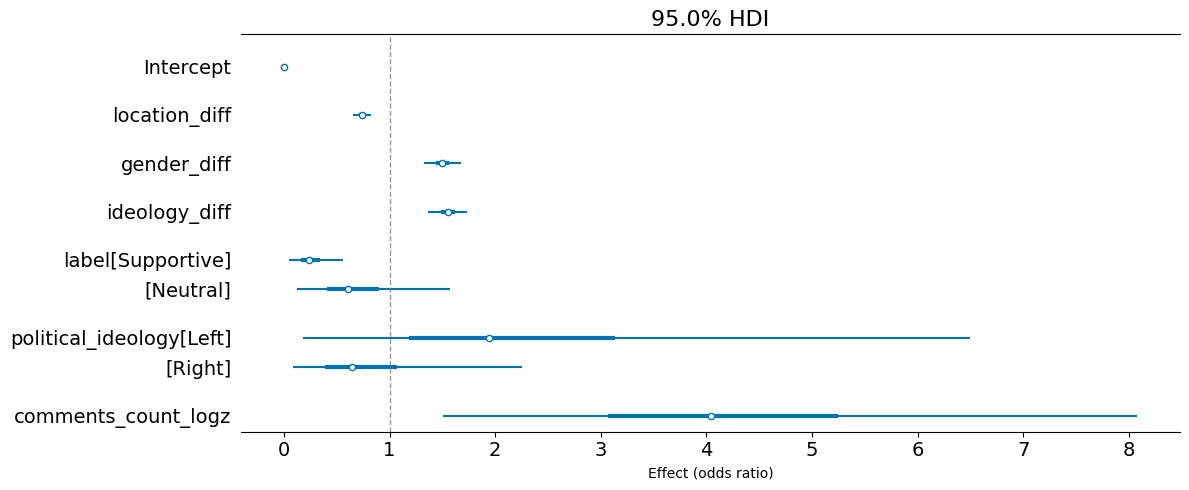

In [57]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
    data=reg_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    # weights = reg_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()